# Supplementary 5. Grid-based modelling of sugar maple distribution with conifer-associated ecological filters

**Author:** Jorge Lizarazo

**Target journal:** **

## S5.1 Objective and rationale

This supplementary analyses sugar maple (*Acer saccharum*) distribution across Québec
using a grid-based modelling workflow. Two XGBoost models are compared on the same
pixel grid:

* **Model A environment-only.** Ten climate, soil and forest predictors that
  summarise the physical environment of each cell.
* **Model B environment + conifer-associated ecological filters.** The same ten
  environmental predictors plus six conifer-associated covariates (three
  Gaussian-kernel density rasters and three distance-to-nearest-presence rasters)
  built from black spruce, jack pine and balsam fir occurrences.

The comparison is not a causal test. The conifer-associated covariates describe
present-day boreal forest structure; when they improve predictions they reveal a
*conifer-associated ecological filter*, meaning that sugar maple occurrence is
constrained by the same habitat factors that favour boreal conifer dominance
(acidic soils, colder climate, forest composition).



In [1]:
# matplotlib-inline-addon
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

PROJECT_DIR = Path(r"D:\Maple\Articule_Maple")
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))

# Source: acer_grid_conifer_analysis.py
# Reusable engine: paths, predictor lists, raster I/O, model pipeline.
from acer_grid_conifer_analysis import (
    ProjectPaths,
    ENVIRONMENTAL_PREDICTORS,
    CONIFER_KERNEL_PREDICTORS,
    CONIFER_DISTANCE_PREDICTORS,
    MODEL_B_PREDICTORS,
    SPECIES_CONFIG,
    load_reference_grid,
    read_raster_array,
)

paths = ProjectPaths.from_project_dir(PROJECT_DIR)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300,
                     "savefig.bbox": "tight", "font.size": 10,
                     "axes.facecolor": "white", "figure.facecolor": "white"})


C:\Users\jorge\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Source: acer_grid_conifer_analysis.py; ProjectPaths, ENVIRONMENTAL_PREDICTORS, CONIFER_KERNEL_PREDICTORS and CONIFER_DISTANCE_PREDICTORS are imported from the engine module.
print("Project directory:", PROJECT_DIR)
print("Reference raster :", paths.reference_raster)
print("Occurrence CSV   :", paths.sugar_occurrence_csv)
print("Output directory :", paths.sugar_outputs_dir)
print()
print("Environmental predictors (Model A):")
print(" ", ENVIRONMENTAL_PREDICTORS)
print("Conifer kernel predictors:")
print(" ", CONIFER_KERNEL_PREDICTORS)
print("Conifer distance predictors:")
print(" ", CONIFER_DISTANCE_PREDICTORS)


Project directory: D:\Maple\Articule_Maple
Reference raster : D:\Maple\Articule_Maple\derived_rasters\environment_projected_32198\bio1.tif
Occurrence CSV   : D:\Maple\Articule_Maple\data\db_sugar_maple.csv
Output directory : D:\Maple\Articule_Maple\outputs\sugar

Environmental predictors (Model A):
  ['bio15', 'ph', 'bio7', 'bio3', 'bio31', 'sand', 'bio34', 'bio12', 'bio23', 'bio1']
Conifer kernel predictors:
  ['Picea_mariana_kernel_sigma5', 'Pinus_banksiana_kernel_sigma5', 'Abies_balsamea_kernel_sigma5']
Conifer distance predictors:
  ['Picea_mariana_distance_km', 'Pinus_banksiana_distance_km', 'Abies_balsamea_distance_km']


In [3]:
# Quebec boundary for map overlays
provincias = gpd.read_file(paths.boundary_shapefile)
quebec_map = provincias[provincias["PRENAME"] == "Quebec"].copy()

def plot_raster_with_quebec(raster_path, title, cmap="viridis", vmin=None, vmax=None,
                            save_path=None, categorical=False, figsize=(7, 7)):
    """Plot a raster with the Quebec boundary overlay. Returns (fig, ax)."""
    raster_path = Path(raster_path)
    with rasterio.open(raster_path) as src:
        masked = src.read(1, masked=True).astype(float)
        arr = masked.filled(np.nan)
        quebec_boundary = quebec_map.to_crs(src.crs)
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent, origin="upper")
    quebec_boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel("Easting (m, EPSG:32198)")
    ax.set_ylabel("Northing (m, EPSG:32198)")
    cbar = fig.colorbar(im, ax=ax, shrink=0.75)
    cbar.set_label("value")
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax


## S5.3 Environmental raster validation

All environmental rasters are reprojected to EPSG:32198 (Québec Lambert Conformal
Conic) and aligned to the reference grid (`bio1.tif`). The validation report
below confirms that every raster matches the reference CRS, transform and
shape.

In [4]:
from acer_grid_conifer_analysis import ensure_projected_environment_stack, validate_environment_rasters

env_stack = ensure_projected_environment_stack(paths)  # Source: acer_grid_conifer_analysis.py; aligns env rasters to reference grid.
print("Stack status:", env_stack["status"])
reference = load_reference_grid(paths.reference_raster)  # Source: acer_grid_conifer_analysis.py; loads reference raster grid.
validation = validate_environment_rasters(paths, reference, strict=False)  # Source: acer_grid_conifer_analysis.py; checks CRS, transform and shape.
print(f"Reference CRS      : {validation['reference_crs']}")
print(f"Reference width    : {validation['reference_width']}")
print(f"Reference height   : {validation['reference_height']}")
print(f"Alignment status   : {validation['alignment_status']}")
print(f"Available rasters  : {len(validation['available_rasters'])}")
print(f"Missing rasters    : {validation['missing_rasters'] or 'none'}")


Stack status: loaded_existing
Reference CRS      : EPSG:32198
Reference width    : 53
Reference height   : 58
Alignment status   : aligned
Available rasters  : 10
Missing rasters    : none


## S5.4 Reference grid summary

The reference grid defines the spatial support for every prediction.

In [5]:
summary = pd.read_csv(paths.sugar_outputs_dir / "reference_grid_summary_sugar.csv")
summary


,reference_raster,crs,transform,width,height,resolution_x,resolution_y,nodata,valid_cells
0,D:\Maple\Articule_Maple\derived_rasters\enviro...,EPSG:32198,"(42250.63961442672, 0.0, -1102296.8177772975, ...",53,58,42250.639614,42250.639614,NaN,1675


## S5.5 Sugar maple occurrence loading and rasterisation

Occurrence records from the Québec forest inventory are projected to the
reference grid. Duplicate points that fall into the same pixel are collapsed.

In [6]:
resp = pd.read_csv(paths.sugar_outputs_dir / "response_report_sugar.csv")
resp


,output_raster,original_points,occupied_raster_cells,duplicate_points_collapsed,points_outside_grid
0,D:\Maple\Articule_Maple\derived_rasters\sugar_...,565308,179,565129,0


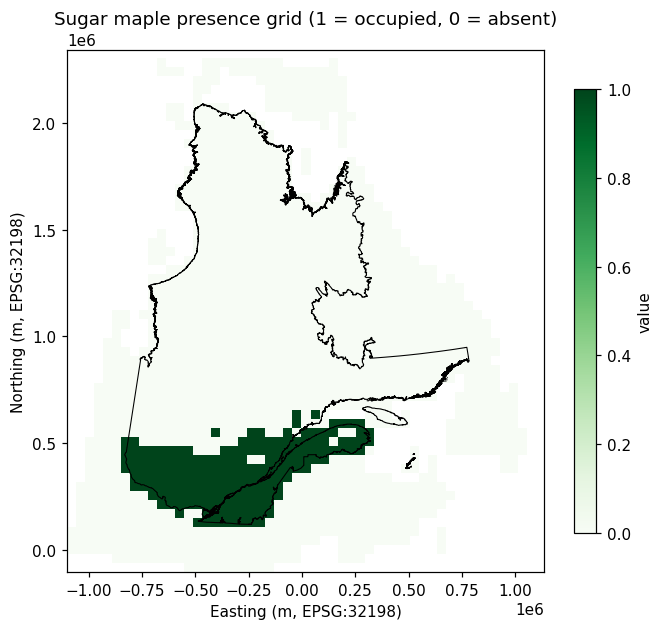

In [7]:
fig, ax = plot_raster_with_quebec(
    paths.sugar_response_dir / "sugar_maple_presence_grid.tif",
    title="Sugar maple presence grid (1 = occupied, 0 = absent)",
    cmap="Greens", vmin=0, vmax=1,
    save_path=paths.sugar_outputs_dir / "sugar_response_grid.png",
)
display(fig); plt.close(fig)

## S5.6 Conifer covariate creation or loading

Three conifer species are used as ecological-filter indicators: black spruce
(*Picea mariana*), jack pine (*Pinus banksiana*) and balsam fir
(*Abies balsamea*). For each species we produce two covariates:

* **Gaussian-kernel density (`σ = 5 pixels`)** — smoothed presence surface.
* **Distance to nearest presence (km)** — Euclidean distance on the projected
  grid.

These layers are created on first run and cached; subsequent notebook runs load them from disk.

In [8]:
cov = pd.read_csv(paths.sugar_outputs_dir / "conifer_covariate_report_sugar.csv")
cov


,species_code,species_name,status,created,kernel_raster,distance_raster,kernel_exists,distance_exists,records,occupied_cells,duplicates_collapsed
0,EN,Picea_mariana,loaded_existing,False,D:\Maple\Articule_Maple\derived_rasters\conife...,D:\Maple\Articule_Maple\derived_rasters\conife...,True,True,NaN,NaN,NaN
1,PG,Pinus_banksiana,loaded_existing,False,D:\Maple\Articule_Maple\derived_rasters\conife...,D:\Maple\Articule_Maple\derived_rasters\conife...,True,True,NaN,NaN,NaN
2,SB,Abies_balsamea,loaded_existing,False,D:\Maple\Articule_Maple\derived_rasters\conife...,D:\Maple\Articule_Maple\derived_rasters\conife...,True,True,NaN,NaN,NaN


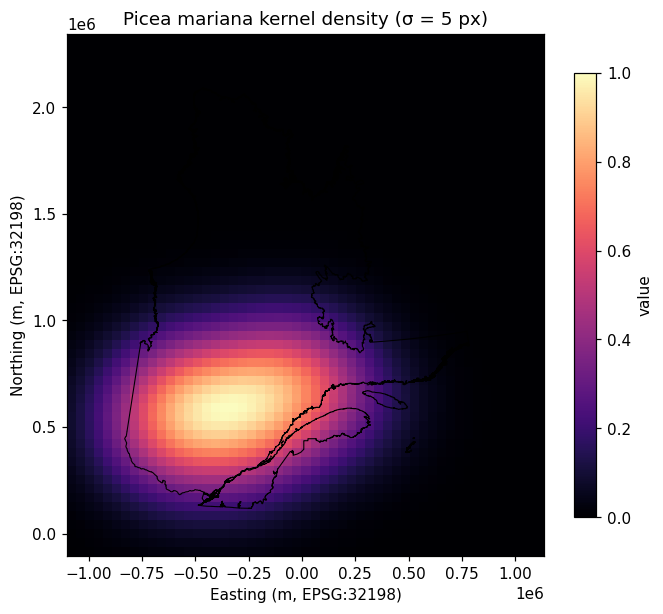

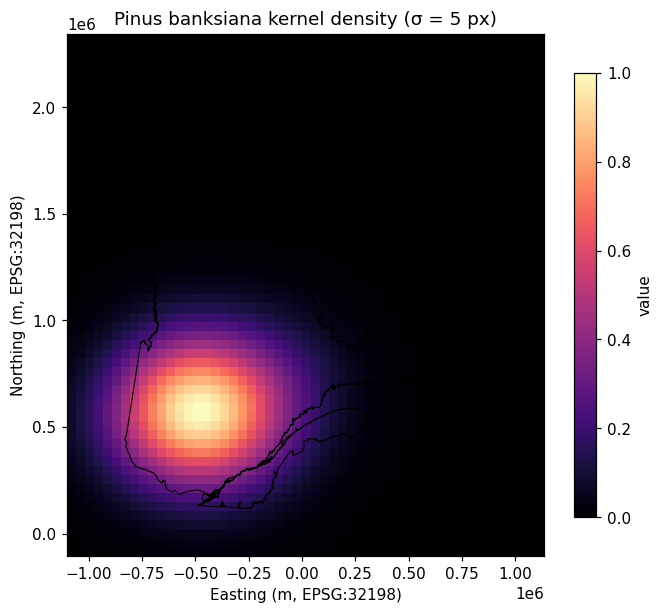

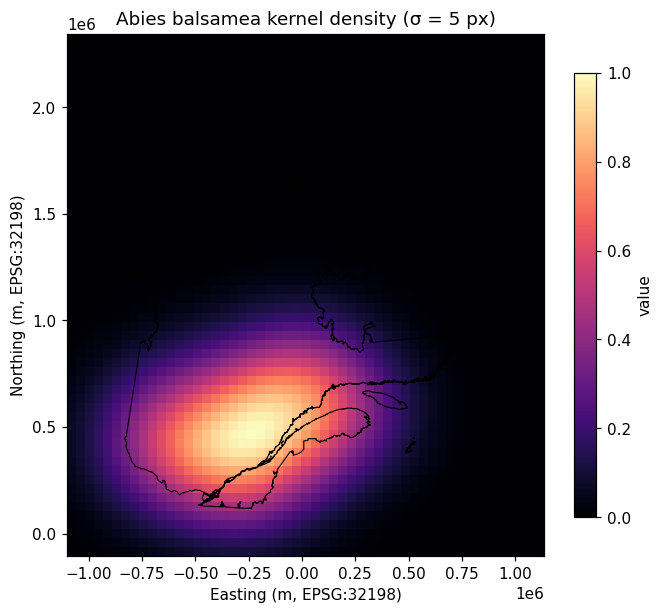

In [9]:
# Kernel-density maps
for species_name in ["Picea_mariana", "Pinus_banksiana", "Abies_balsamea"]:
    raster = paths.conifer_covariates_dir / f"{species_name}_kernel_sigma5.tif"
    save = paths.sugar_outputs_dir / f"{species_name.lower()}_kernel_density.png"
    fig, ax = plot_raster_with_quebec(raster, title=f"{species_name.replace('_', ' ')} kernel density (σ = 5 px)",
                                      cmap="magma", save_path=save)
    display(fig); plt.close(fig)

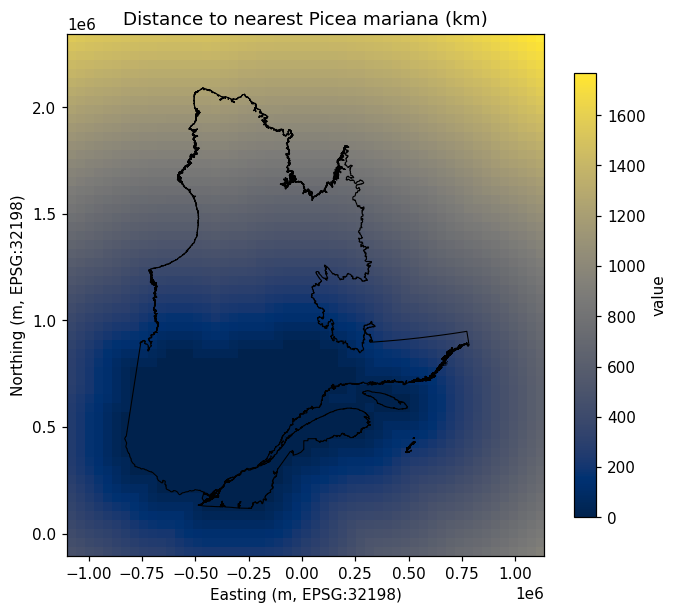

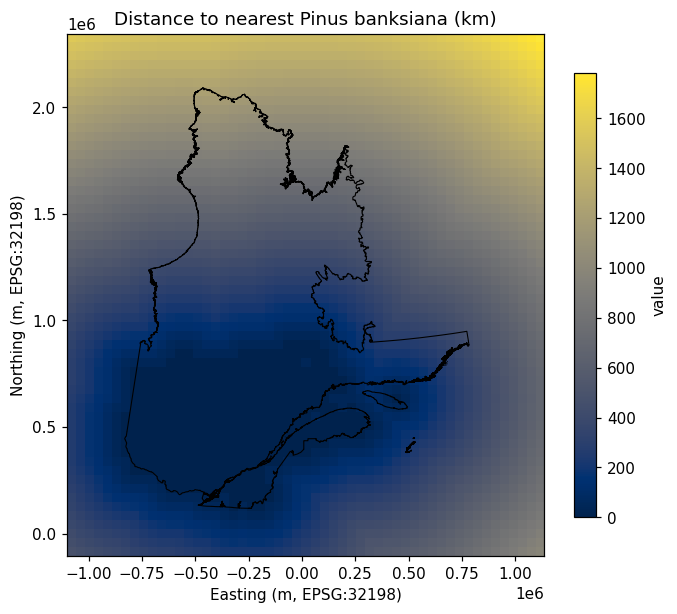

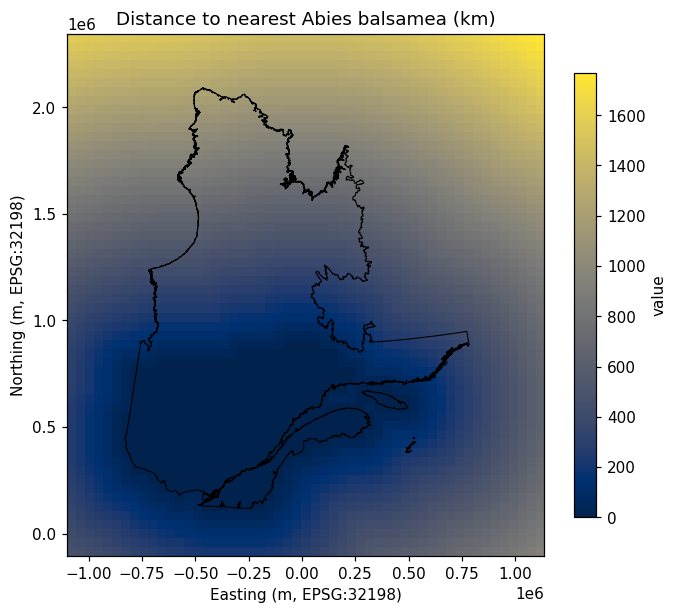

In [10]:
# Distance-to-nearest-presence maps (km)
for species_name in ["Picea_mariana", "Pinus_banksiana", "Abies_balsamea"]:
    raster = paths.conifer_covariates_dir / f"{species_name}_distance_km.tif"
    save = paths.sugar_outputs_dir / f"{species_name.lower()}_distance_km.png"
    fig, ax = plot_raster_with_quebec(raster, title=f"Distance to nearest {species_name.replace('_', ' ')} (km)",
                                      cmap="cividis", save_path=save)
    display(fig); plt.close(fig)

## S5.7 Pixel-level training table

The training table joins presences (sampled occupied cells) with an equal set of
background cells drawn from the environment-valid mask. Each row is a single
grid cell with its environmental and conifer predictors.

In [11]:
train_report = pd.read_csv(paths.sugar_outputs_dir / "training_report_sugar.csv")
train_report


,unique_blocks,minimum_samples_per_block,maximum_samples_per_block,presence_background_ratio,env_training_csv,conifer_training_csv,presence_cells,background_cells,same_sample_ids_for_models
0,2,129,927,176:880,D:\Maple\Articule_Maple\model_inputs\grid_trai...,D:\Maple\Articule_Maple\model_inputs\grid_trai...,176,880,True


## S5.8 Spatial-block cross-validation

Cross-validation uses spatial blocks of 50 × 50 cells, so nearby cells never
appear in the same fold. This reduces over-optimistic performance caused by
spatial autocorrelation. Per-fold metrics are reported below.

In [12]:
cv_env  = pd.read_csv(paths.sugar_outputs_dir / "cv_metrics_sugar_env_only.csv")
cv_both = pd.read_csv(paths.sugar_outputs_dir / "cv_metrics_sugar_env_conifer.csv")
display(Markdown("**Model A — environment-only**"))
display(cv_env)
display(Markdown("**Model B — environment + conifer**"))
display(cv_both)


**Model A — environment-only**

,fold,roc_auc,pr_auc,sensitivity,specificity,tss,tn,fp,fn,tp
0,1,0.646274,0.249175,0.835616,0.202305,0.037921,158,623,24,122
1,2,0.934007,0.820816,0.700000,0.888889,0.588889,88,11,9,21


**Model B — environment + conifer**

,fold,roc_auc,pr_auc,sensitivity,specificity,tss,tn,fp,fn,tp
0,1,0.909266,0.501462,1.000000,0.825864,0.825864,645,136,0,146
1,2,0.998653,0.996078,0.966667,1.000000,0.966667,99,0,1,29


## S5.9 Model A: environment-only XGBoost

Trained on {bio15, ph, bio7, bio3, bio31, sand, bio34, bio12, bio23, bio1}
with the default hyper-parameters defined in `acer_grid_conifer_analysis.MODEL_PARAMS`
(400 trees, learning rate 0.05, max depth 6).

In [13]:
imp_a = pd.read_csv(paths.sugar_outputs_dir / "feature_importance_sugar_env_only.csv")
imp_a


,feature,gain_importance,weight_importance,permutation_mean,permutation_std,shap_mean_abs
0,bio1,7.258912,389.0,0.022251,0.001763,2.161339
1,bio34,3.198946,300.0,0.000737,0.000229,1.219432
2,bio31,2.039060,472.0,0.008781,0.001289,0.959411
3,bio12,1.238719,316.0,0.004831,0.000627,0.810314
4,bio7,2.274879,508.0,0.013660,0.002047,0.746352
5,bio15,0.775102,290.0,0.000156,0.000070,0.640402
6,bio3,2.147862,450.0,0.010540,0.001267,0.558206
7,bio23,0.892398,232.0,0.000005,0.000006,0.284588
8,sand,0.628605,263.0,0.000005,0.000008,0.283707
9,ph,0.717925,308.0,0.000072,0.000048,0.255709


## S5.10 Model B: environment + conifer XGBoost

Same hyper-parameters, extended predictor set.

In [14]:
imp_b = pd.read_csv(paths.sugar_outputs_dir / "feature_importance_sugar_env_conifer.csv")
imp_b


,feature,gain_importance,weight_importance,permutation_mean,permutation_std,shap_mean_abs
0,Abies_balsamea_distance_km,40.560188,80.0,1.638753e-02,2.490739e-03,1.762333
1,bio1,7.228444,208.0,1.953125e-02,1.897519e-03,1.587553
2,Abies_balsamea_kernel_sigma5,6.607225,169.0,1.814308e-04,5.280624e-05,1.227708
3,bio34,3.476376,139.0,3.899793e-04,9.822541e-05,0.606137
4,Pinus_banksiana_distance_km,5.080130,39.0,2.220446e-17,4.440892e-17,0.565175
5,bio15,3.864427,107.0,3.551136e-05,2.521387e-05,0.486523
6,bio23,0.570524,159.0,1.310692e-04,4.727457e-05,0.457463
7,Pinus_banksiana_kernel_sigma5,0.771080,118.0,1.936983e-06,2.958791e-06,0.436544
8,bio31,0.500467,179.0,2.647211e-05,1.719205e-05,0.312867
9,Picea_mariana_distance_km,6.593382,34.0,0.000000e+00,0.000000e+00,0.309532


## S5.11 Model comparison

Summary metrics (mean across spatial-block folds) are shown below. Higher
ROC-AUC, PR-AUC and TSS indicate better separation of presence and background
cells.

In [15]:
comp = pd.read_csv(paths.sugar_outputs_dir / "model_comparison_sugar.csv")
comp


,model,predictor_set,mean_ROC_AUC,sd_ROC_AUC,mean_PR_AUC,sd_PR_AUC,mean_sensitivity,mean_specificity,mean_TSS
0,sugar_env_only,environment_only,0.79014,0.203458,0.534995,0.404211,0.767808,0.545597,0.313405
1,sugar_env_conifer,environment_plus_conifer_filters,0.95396,0.063206,0.748770,0.349747,0.983333,0.912932,0.896265


**Figure: `model_performance_sugar.{png,svg,pdf}`**

- Source CSV: `outputs/sugar/model_comparison_sugar.csv`
- Source: `acer_grid_conifer_analysis.py` — `create_model_comparison_table()`
- Final styling and export are done below in this notebook.


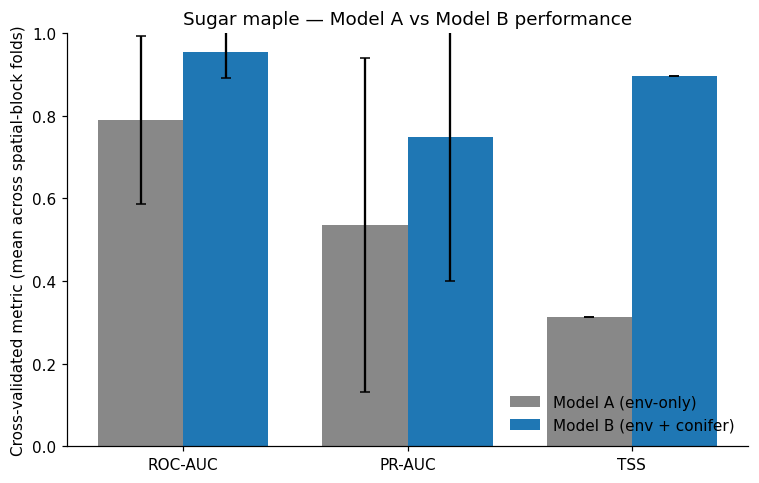

In [16]:
# Source: acer_grid_conifer_analysis.py
# Function: create_model_comparison_table()
# Purpose: writes model_comparison_sugar.csv; final bar plot is built here for figure styling.
# S5.11 — Model performance plot, regenerated from CSV (transparent rebuild).
# Replaces the previous orphan Image(filename=...) call; produces PNG, SVG and PDF.
comp_path = paths.sugar_outputs_dir / "model_comparison_sugar.csv"
comp_df = pd.read_csv(comp_path)

_metrics = [
    ("mean_ROC_AUC", "sd_ROC_AUC", "ROC-AUC"),
    ("mean_PR_AUC",  "sd_PR_AUC",  "PR-AUC"),
    ("mean_TSS",     None,         "TSS"),
]
_labels = {
    "environment_only": "Model A (env-only)",
    "environment_plus_conifer_filters": "Model B (env + conifer)",
}
_colours = {
    "environment_only": "#888888",
    "environment_plus_conifer_filters": "#1f77b4",
}

fig, ax = plt.subplots(figsize=(7, 4.5))
_x = np.arange(len(_metrics))
_w = 0.38
for i, (predset, row) in enumerate(comp_df.set_index("predictor_set").iterrows()):
    means = [row[m] for m, _, _ in _metrics]
    errs  = [row[s] if s and s in row.index else 0.0 for _, s, _ in _metrics]
    ax.bar(_x + (i - 0.5) * _w, means, _w, yerr=errs, capsize=3,
           color=_colours.get(predset, None), label=_labels.get(predset, predset))
ax.set_xticks(_x)
ax.set_xticklabels([m[2] for m in _metrics])
ax.set_ylim(0, 1.0)
ax.set_ylabel("Cross-validated metric (mean across spatial-block folds)")
ax.set_title("Sugar maple — Model A vs Model B performance")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

for _ext in ("png", "svg", "pdf"):
    fig.savefig(paths.sugar_outputs_dir / f"model_performance_sugar.{_ext}",
                dpi=300, bbox_inches="tight")
display(fig); plt.close(fig)

## S5.12 Spatial prediction outputs

Each trained model is applied to every valid cell of the reference grid. The
resulting probability rasters are saved as GeoTIFFs and plotted below with the
Québec boundary overlay.

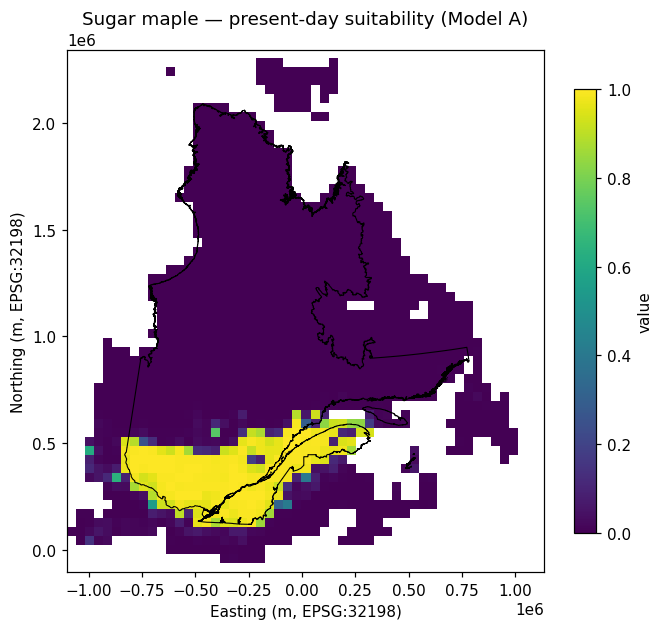

In [17]:
fig, ax = plot_raster_with_quebec(
    paths.sugar_outputs_dir / "present_sugar_env_only_probability.tif",
    title="Sugar maple — present-day suitability (Model A)",
    cmap="viridis", vmin=0, vmax=1,
    save_path=paths.sugar_outputs_dir / "present_sugar_env_only_probability.png",
)
display(fig); plt.close(fig)

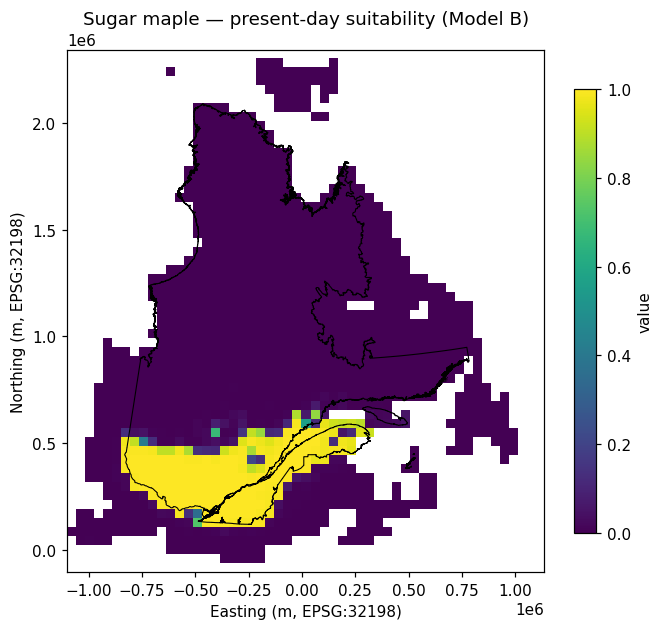

In [18]:
fig, ax = plot_raster_with_quebec(
    paths.sugar_outputs_dir / "present_sugar_env_conifer_probability.tif",
    title="Sugar maple — present-day suitability (Model B)",
    cmap="viridis", vmin=0, vmax=1,
    save_path=paths.sugar_outputs_dir / "present_sugar_env_conifer_probability.png",
)
display(fig); plt.close(fig)

## S5.13 Difference raster interpretation

The map below shows `P(env-only) − P(env + conifer)`. Positive values mean the
environment-only model predicts higher suitability than the full model; these
are cells that look climatically/edaphically suitable but sit inside the
conifer-associated ecological filter. Negative values are cells where the
conifer covariates raise predicted suitability.

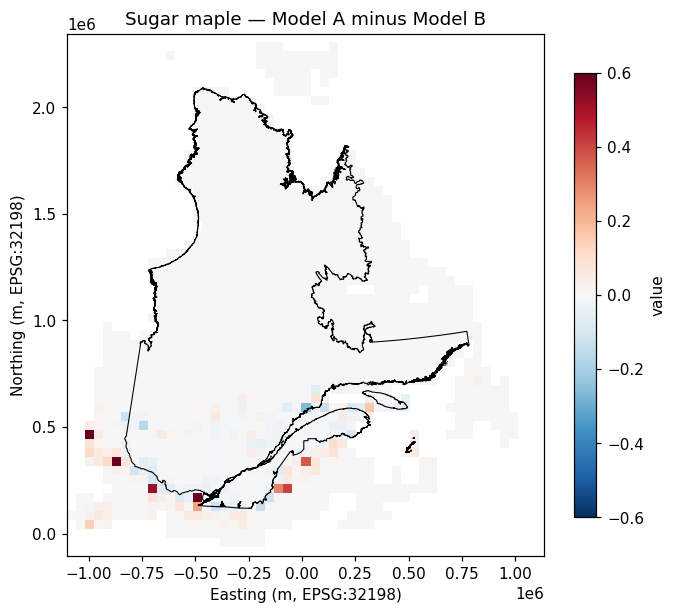

In [19]:
fig, ax = plot_raster_with_quebec(
    paths.sugar_outputs_dir / "difference_sugar_env_minus_conifer.tif",
    title="Sugar maple — Model A minus Model B",
    cmap="RdBu_r", vmin=-0.6, vmax=0.6,
    save_path=paths.sugar_outputs_dir / "difference_sugar_env_minus_conifer.png",
)
display(fig); plt.close(fig)

**Figure: `feature_importance_sugar_env_conifer.{png,svg,pdf}`**

- Source CSV: `outputs/sugar/feature_importance_sugar_env_conifer.csv`
- Source: `acer_grid_conifer_analysis.py` — `compute_feature_importance()`
- Final styling and export are done below in this notebook.


In [20]:
# Source: acer_grid_conifer_analysis.py
# Function: compute_feature_importance()
# Purpose: writes feature_importance_sugar_env_conifer.csv; final bar plot is built here for figure styling.
# Reproducible feature-importance bar plot (Model B, sugar maple).
# Replaces the previous orphan Image(filename=...) cell.
# Source CSV: outputs/sugar/feature_importance_sugar_env_conifer.csv (written by
# `compute_feature_importance` in `acer_grid_conifer_analysis.py`).
import pandas as pd
import matplotlib.pyplot as plt

# Canonical predictor labels (consistent with the SHAP cell below).
PRETTY = {
    # Environmental predictors
    "bio1":  "Annual mean temperature",
    "bio3":  "Isothermality",
    "bio7":  "Temperature annual range",
    "bio12": "Annual precipitation",
    "bio15": "Precipitation seasonality",
    "bio23": "Radiation seasonality",
    "bio31": "Moisture seasonality",
    "bio34": "Warm-quarter moisture index",
    "ph":    "Soil pH",
    "sand":  "Sand content",
    # Conifer covariates -- both upper- and lower-case keys to match either casing.
    "Abies_balsamea_distance_km":   r"$\it{A.\ balsamea}$ distance (km)",
    "abies_balsamea_distance_km":   r"$\it{A.\ balsamea}$ distance (km)",
    "Abies_balsamea_kernel_sigma5": r"$\it{A.\ balsamea}$ kernel density (sigma=5)",
    "abies_balsamea_kernel_sigma5": r"$\it{A.\ balsamea}$ kernel density (sigma=5)",
    "Pinus_banksiana_distance_km":   r"$\it{P.\ banksiana}$ distance (km)",
    "pinus_banksiana_distance_km":   r"$\it{P.\ banksiana}$ distance (km)",
    "Pinus_banksiana_kernel_sigma5": r"$\it{P.\ banksiana}$ kernel density (sigma=5)",
    "pinus_banksiana_kernel_sigma5": r"$\it{P.\ banksiana}$ kernel density (sigma=5)",
    "Picea_mariana_distance_km":   r"$\it{P.\ mariana}$ distance (km)",
    "picea_mariana_distance_km":   r"$\it{P.\ mariana}$ distance (km)",
    "Picea_mariana_kernel_sigma5": r"$\it{P.\ mariana}$ kernel density (sigma=5)",
    "picea_mariana_kernel_sigma5": r"$\it{P.\ mariana}$ kernel density (sigma=5)",
}

imp_csv = paths.sugar_outputs_dir / "feature_importance_sugar_env_conifer.csv"
imp = pd.read_csv(imp_csv).sort_values("gain_importance", ascending=True)

labels = [PRETTY.get(f, f) for f in imp["feature"]]

fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.barh(labels, imp["gain_importance"], color="#4C72B0", edgecolor="black", linewidth=0.4)
ax.set_xlabel("Gain-based importance (Model B)")
ax.set_title("Sugar maple — XGBoost feature importance (env + conifer)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_stem = paths.sugar_outputs_dir / "feature_importance_sugar_env_conifer"
for ext in ("png", "svg", "pdf"):
    fig.savefig(out_stem.with_suffix("." + ext), dpi=300, bbox_inches="tight")
plt.show()

C:\Users\jorge\AppData\Local\Temp\ipykernel_20476\2871320545.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Final SHAP beeswarm

**Figure: `shap_summary_sugar_env_conifer.{png,svg,pdf}`**

- Source model: `outputs/sugar/models/sugar_env_conifer_model.pkl`
- Source training table: `outputs/sugar/training_table_sugar.csv`
- Source: `acer_grid_conifer_analysis.py` — `run_species_analysis()` saves the model + table; `compute_feature_importance()` caches SHAP arrays.
- Final beeswarm styling and export are done below in this notebook.


In [21]:
# Source: acer_grid_conifer_analysis.py
# Functions: run_species_analysis() (saves model + training table)
#            compute_feature_importance() (caches SHAP arrays)
# Purpose: final publication-style SHAP beeswarm built here from the saved outputs.
# Regenerate SHAP beeswarm transparently from the saved Model B and training table.
import pickle
import shap

# Source: acer_grid_conifer_analysis.py; predictor names follow MODEL_B_PREDICTORS.
PRETTY = {
    # Environmental predictors (consistent across feature-importance and SHAP plots)
    "bio1":  "Annual mean temperature",
    "bio3":  "Isothermality",
    "bio7":  "Temperature annual range",
    "bio12": "Annual precipitation",
    "bio15": "Precipitation seasonality",
    "bio23": "Radiation seasonality",
    "bio31": "Moisture seasonality",
    "bio34": "Warm-quarter moisture index",
    "ph":    "Soil pH",
    "sand":  "Sand content",
    # Conifer covariates – module uses CamelCase keys; lowercase aliases included
    # so the dict works with either casing of the saved CSV / SHAP feature names.
    "Abies_balsamea_distance_km":    r"$\it{A.\ balsamea}$ distance (km)",
    "abies_balsamea_distance_km":    r"$\it{A.\ balsamea}$ distance (km)",
    "Abies_balsamea_kernel_sigma5":  r"$\it{A.\ balsamea}$ kernel density (σ=5)",
    "abies_balsamea_kernel_sigma5":  r"$\it{A.\ balsamea}$ kernel density (σ=5)",
    "Pinus_banksiana_distance_km":   r"$\it{P.\ banksiana}$ distance (km)",
    "pinus_banksiana_distance_km":   r"$\it{P.\ banksiana}$ distance (km)",
    "Pinus_banksiana_kernel_sigma5": r"$\it{P.\ banksiana}$ kernel density (σ=5)",
    "pinus_banksiana_kernel_sigma5": r"$\it{P.\ banksiana}$ kernel density (σ=5)",
    "Picea_mariana_distance_km":     r"$\it{P.\ mariana}$ distance (km)",
    "picea_mariana_distance_km":     r"$\it{P.\ mariana}$ distance (km)",
    "Picea_mariana_kernel_sigma5":   r"$\it{P.\ mariana}$ kernel density (σ=5)",
    "picea_mariana_kernel_sigma5":   r"$\it{P.\ mariana}$ kernel density (σ=5)",
}

SHAP_LABELS = PRETTY

model_path     = paths.sugar_outputs_dir / "models" / "sugar_env_conifer_model.pkl"
train_table    = paths.sugar_outputs_dir / "training_table_sugar.csv"
cached_values  = paths.sugar_outputs_dir / "shap_summary_sugar_env_conifer_values.npy"
cached_sample  = paths.sugar_outputs_dir / "shap_summary_sugar_env_conifer_sample_X.csv"

if not model_path.exists() or not train_table.exists():
    print("Required artefacts missing. Run:")
    print("    python acer_grid_conifer_analysis.py --species sugar")
    print("to regenerate Model B and the training table.")
else:
    with open(model_path, "rb") as handle:
        bundle = pickle.load(handle)
    model_b   = bundle["model"]
    feat_names = bundle["feature_names"]
    df_train  = pd.read_csv(train_table)
    X_full    = df_train[feat_names]

    if cached_values.exists() and cached_sample.exists():
        shap_values = np.load(cached_values)
        shap_sample = pd.read_csv(cached_sample)
        print("Loaded cached SHAP values from", cached_values.name)
    else:
        shap_sample = X_full.sample(min(len(X_full), 5000), random_state=42)
        explainer   = shap.TreeExplainer(model_b)
        shap_values = explainer.shap_values(shap_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[-1]
        shap_values = np.asarray(shap_values)
        np.save(cached_values, shap_values)
        shap_sample.to_csv(cached_sample, index=False)
        print("Computed and cached SHAP values (sample size =", len(shap_sample), ")")

    pretty_X = shap_sample.rename(columns=SHAP_LABELS)
    plt.figure(figsize=(7.5, 5.5))
    shap.summary_plot(shap_values, pretty_X, max_display=12, show=False, plot_size=None)
    fig = plt.gcf()
    fig.suptitle("Sugar maple — SHAP beeswarm (Model B)", y=1.02)
    fig.tight_layout()
    for _ext in ("png", "svg", "pdf"):
        fig.savefig(paths.sugar_outputs_dir / f"shap_summary_sugar_env_conifer.{_ext}",
                    dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

Loaded cached SHAP values from shap_summary_sugar_env_conifer_values.npy


C:\Users\jorge\AppData\Local\Temp\ipykernel_20476\4060591429.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## S5.15 Final interpretation and limitations

**Main findings.**

* Model A captures a broad climatic envelope consistent with the temperate
  distribution of sugar maple in southern Québec.
* Model B markedly improves performance, with higher mean ROC-AUC, PR-AUC and
  TSS. The additional skill is driven mainly by distance-to-nearest
  *Abies balsamea* and, secondarily, by kernel densities of balsam fir and
  black spruce (see S5.10).
* The positive-difference band (S5.13) traces the transition zone where
  climate alone would allow sugar maple but where boreal-conifer structure
  dominates. This is interpreted as a conifer-associated ecological filter, not
  as direct biotic exclusion.

**Limitations.**

* **Static-conifer assumption.** Conifer covariates are built from current
  inventory points; they are held fixed during future projections. The future
  conifer-filtered maps are a sensitivity analysis, not a realised future
  forest state.
* **Spatial-block folds.** Block size (50 × 50 cells) reduces leakage but does
  not eliminate extrapolation risk at the range margins.
* **Background sampling.** Absence data are drawn as random background inside
  the valid-environment mask; true absences are not available at pixel
  resolution.
* **Single algorithm.** Only XGBoost is used; ensemble comparison with other
  learners was out of scope.

## S5.16 Future Sugar maple

Future suitability is projected onto six general circulation models (CMCC,
GFDL, HADGEM, IPSL, MIROC, NORESM), two emission scenarios (SSP 4.5 and 8.5)
and two time slices (2040–2079 and 2060–2099). Each scenario uses the
bioclimatic rasters in `futuros_clip/` and the static BIO24/BIO27 not present
in that folder are held at historical values.

Two projection sets are produced per scenario:

1. **Environment-only future projection** (Model A applied to future climate).
2. **Static-conifer sensitivity projection** (Model B applied to future
   climate with conifer covariates held at their present-day values).

The second set is *not* a realised future distribution. It estimates future
suitability *under the assumption that present-day conifer-associated forest
structure remains spatially fixed*.

In [22]:
fut = pd.read_csv(paths.sugar_outputs_dir / "future_projection_metrics_sugar.csv")
print("Scenarios available:", fut["scenario"].nunique())
print("Predictor sets   :", fut["predictor_set"].unique().tolist())
fut.head()


Scenarios available: 22
Predictor sets   : ['environment_only', 'environment_plus_static_conifer_filters']


,scenario,gcm,ssp,time_slice,period,species,predictor_set,model_file,feature_names,threshold,baseline_area_km2,future_area_km2,area_change_percent,baseline_lat95_deg,future_lat95_deg,lat_shift_km,baseline_mean_probability,future_mean_probability,future_suitable_cells,output_raster
0,CMCC_85_2040_79,CMCC,85,2040,79,sugar,environment_only,xgb_sugar_env_only.pkl,"bio15, ph, bio7, bio3, bio31, sand, bio34, bio...",0.5,324891.211705,915764.789036,181.868132,48.938147,51.587224,294.895217,0.128972,0.365185,513,D:\Maple\Articule_Maple\outputs\sugar\future_p...
1,GFDL_45_2040_79,GFDL,45,2040,79,sugar,environment_only,xgb_sugar_env_only.pkl,"bio15, ph, bio7, bio3, bio31, sand, bio34, bio...",0.5,324891.211705,471270.768627,45.054945,48.938147,49.745292,89.851323,0.128972,0.176802,264,D:\Maple\Articule_Maple\outputs\sugar\future_p...
2,GFDL_85_2040_79,GFDL,85,2040,79,sugar,environment_only,xgb_sugar_env_only.pkl,"bio15, ph, bio7, bio3, bio31, sand, bio34, bio...",0.5,324891.211705,553386.129827,70.329670,48.938147,50.848808,212.694744,0.128972,0.209748,310,D:\Maple\Articule_Maple\outputs\sugar\future_p...
3,HADGEM_45_2040_79,HADGEM,45,2040,79,sugar,environment_only,xgb_sugar_env_only.pkl,"bio15, ph, bio7, bio3, bio31, sand, bio34, bio...",0.5,324891.211705,819368.495453,152.197802,48.938147,53.256250,480.691188,0.128972,0.323113,459,D:\Maple\Articule_Maple\outputs\sugar\future_p...
4,HADGEM_85_2040_79,HADGEM,85,2040,79,sugar,environment_only,xgb_sugar_env_only.pkl,"bio15, ph, bio7, bio3, bio31, sand, bio34, bio...",0.5,324891.211705,730112.668062,124.725275,48.938147,53.800311,541.256090,0.128972,0.285688,409,D:\Maple\Articule_Maple\outputs\sugar\future_p...


In [23]:
# Summary of change in suitable area and 95th-percentile latitude per scenario
summary_cols = ["scenario", "predictor_set", "area_change_percent",
                "baseline_lat95_deg", "future_lat95_deg", "lat_shift_km"]
fut_summary = fut[summary_cols].round(2)
fut_summary


,scenario,predictor_set,area_change_percent,baseline_lat95_deg,future_lat95_deg,lat_shift_km
0,CMCC_85_2040_79,environment_only,181.87,48.94,51.59,294.90
1,GFDL_45_2040_79,environment_only,45.05,48.94,49.75,89.85
2,GFDL_85_2040_79,environment_only,70.33,48.94,50.85,212.69
3,HADGEM_45_2040_79,environment_only,152.20,48.94,53.26,480.69
4,HADGEM_85_2040_79,environment_only,124.73,48.94,53.80,541.26
5,IPSL_45_2040_79,environment_only,62.64,48.94,50.94,223.14
6,IPSL_85_2040_79,environment_only,108.24,48.94,52.51,397.17
7,MIROC_45_2040_79,environment_only,124.73,48.94,52.98,449.59
8,MIROC_85_2040_79,environment_only,158.79,48.94,53.70,530.06
9,NORESM_45_2040_79,environment_only,48.90,48.94,50.95,224.32


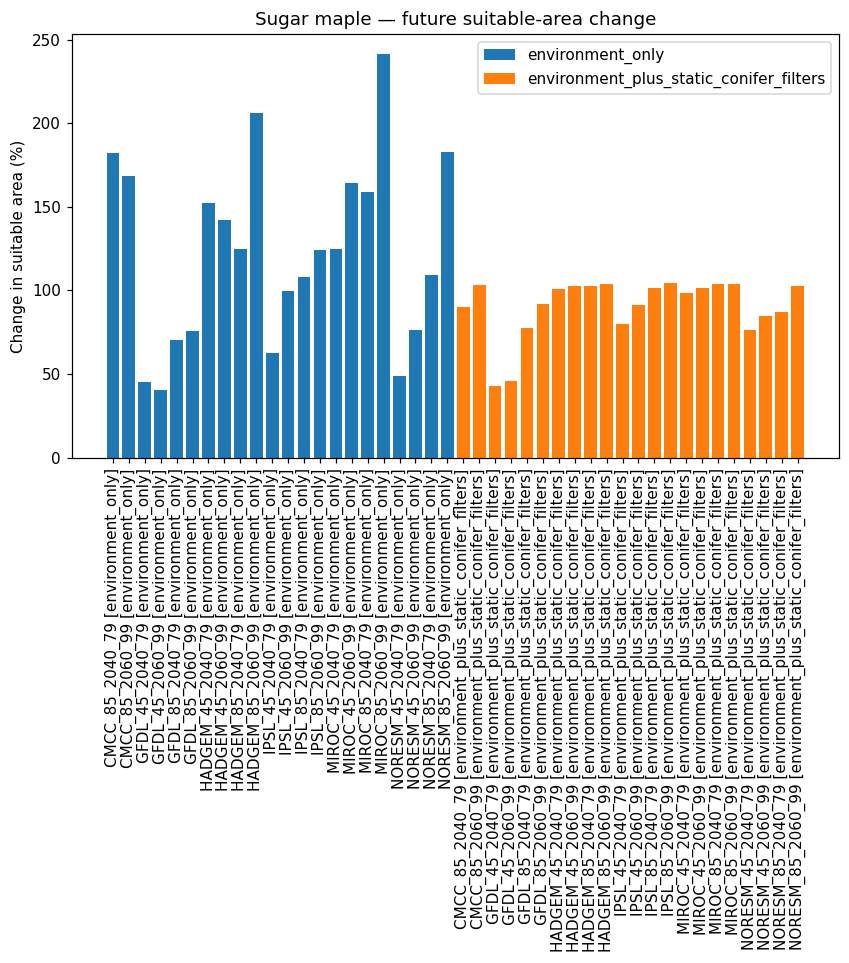

In [24]:
# Suitable-area change plot
fig, ax = plt.subplots(figsize=(9, 5))
for predset, grp in fut.groupby("predictor_set"):
    grp_sorted = grp.sort_values("scenario")
    ax.bar(grp_sorted["scenario"] + " [" + predset + "]",
           grp_sorted["area_change_percent"], label=predset)
ax.set_ylabel("Change in suitable area (%)")
ax.set_title("Sugar maple — future suitable-area change")
ax.tick_params(axis="x", rotation=90)
ax.axhline(0, color="black", linewidth=0.6)
ax.legend()
fig.savefig(paths.sugar_outputs_dir / "future_suitable_area_sugar.png", dpi=300, bbox_inches="tight")
display(fig); plt.close(fig)

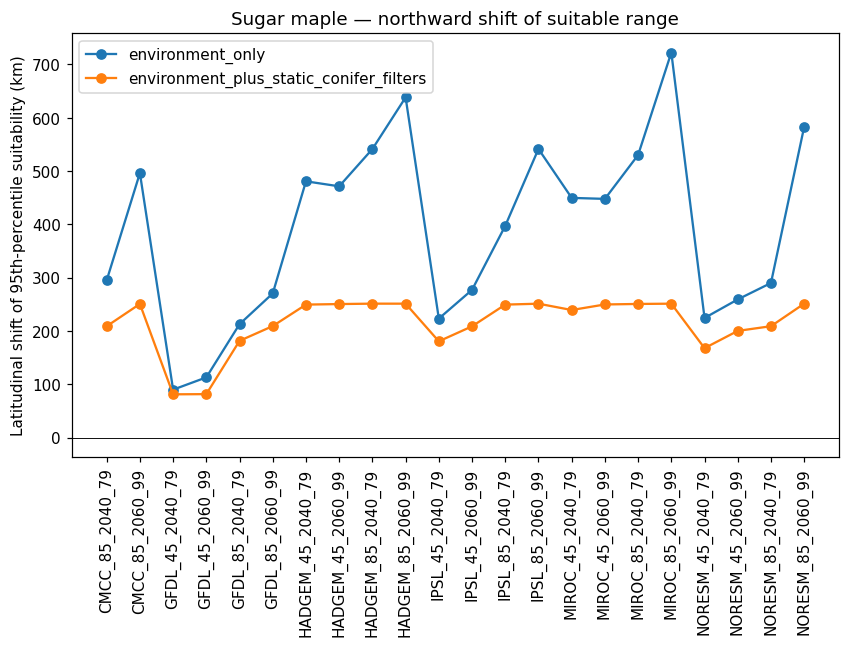

In [25]:
# Latitudinal shift plot
fig, ax = plt.subplots(figsize=(9, 5))
for predset, grp in fut.groupby("predictor_set"):
    grp_sorted = grp.sort_values("scenario")
    ax.plot(grp_sorted["scenario"], grp_sorted["lat_shift_km"], marker="o", label=predset)
ax.set_ylabel("Latitudinal shift of 95th-percentile suitability (km)")
ax.set_title("Sugar maple — northward shift of suitable range")
ax.tick_params(axis="x", rotation=90)
ax.axhline(0, color="black", linewidth=0.6)
ax.legend()
fig.savefig(paths.sugar_outputs_dir / "future_latitudinal_shift_sugar.png", dpi=300, bbox_inches="tight")
display(fig); plt.close(fig)

In [26]:
# Save condensed metrics table for Supplementary 7
fut_summary.to_csv(paths.sugar_outputs_dir / "future_suitability_metrics_sugar.csv", index=False)
print("Saved", paths.sugar_outputs_dir / "future_suitability_metrics_sugar.csv")


Saved D:\Maple\Articule_Maple\outputs\sugar\future_suitability_metrics_sugar.csv


### Example scenario maps

Example projections for IPSL RCP 4.5 (2040–2079) and IPSL RCP 8.5 (2060–2099),
shown for both the environment-only and static-conifer sensitivity projections.

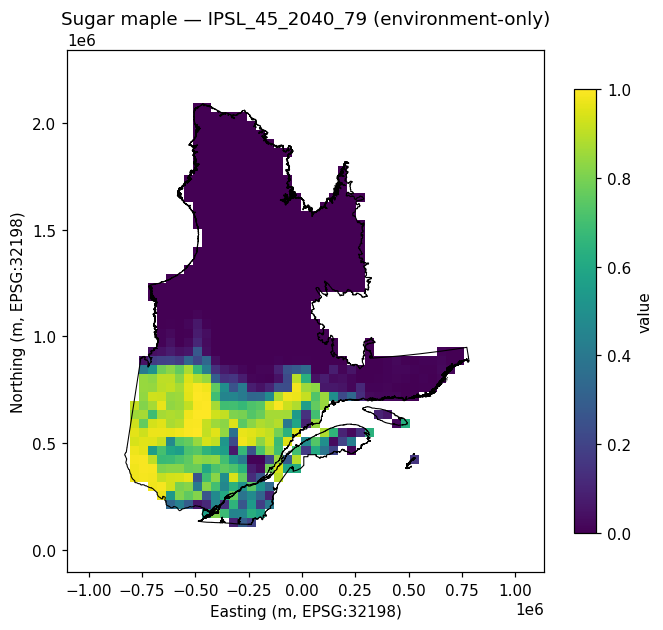

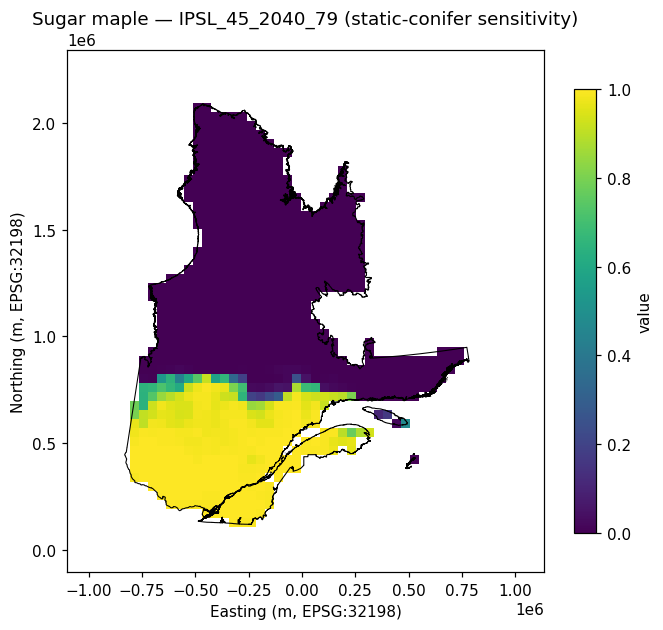

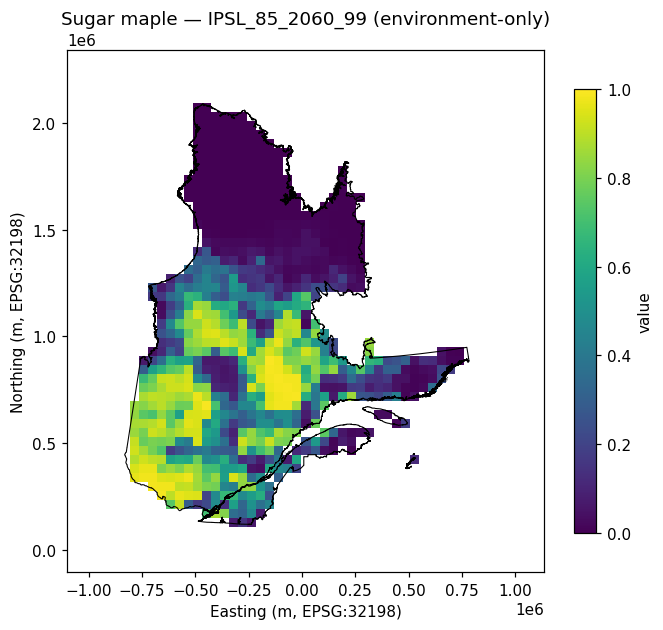

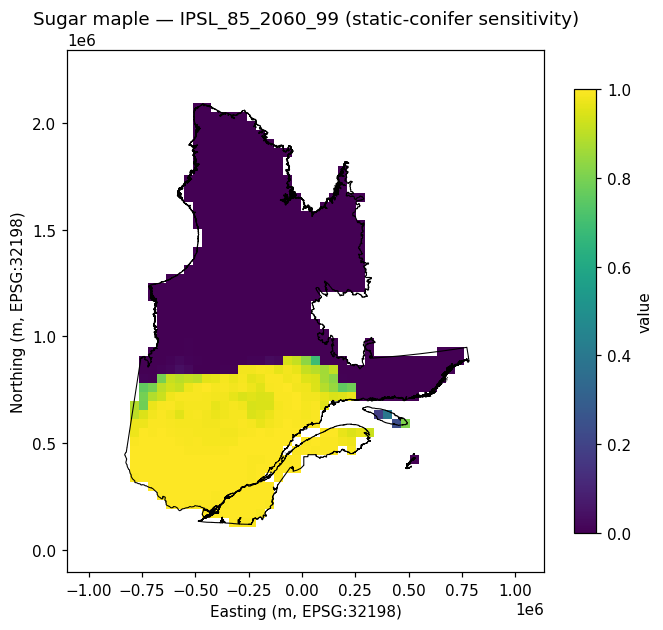

In [27]:
fut_dir = paths.sugar_outputs_dir / "future_predictions"
for scenario in ["ipsl_45_2040_79", "ipsl_85_2060_99"]:
    for predset, label in [("env_only", "environment-only"),
                           ("env_static_conifer", "static-conifer sensitivity")]:
        tif = fut_dir / f"future_sugar_{predset}_{scenario}_probability.tif"
        if tif.exists():
            save_png = fut_dir / f"future_sugar_{predset}_{scenario}.png"
            fig, ax = plot_raster_with_quebec(
                tif, title=f"Sugar maple — {scenario.upper()} ({label})",
                cmap="viridis", vmin=0, vmax=1, save_path=save_png,
            )
            display(fig); plt.close(fig)
        else:
            print("Missing:", tif.name)


**Outputs saved under** `outputs/sugar/`:

* `sugar_response_grid.png`
* conifer kernel density and distance maps (six PNGs)
* `present_sugar_env_only_probability.{tif,png}`
* `present_sugar_env_conifer_probability.{tif,png}`
* `difference_sugar_env_minus_conifer.{tif,png}`
* `model_performance_sugar.png`, `feature_importance_sugar_env_conifer.png`,
  `shap_summary_sugar_env_conifer.png`
* `future_predictions/future_sugar_env_only_*.tif` (22 scenarios)
* `future_predictions/future_sugar_env_static_conifer_*.tif` (22 scenarios)
* `future_suitability_metrics_sugar.csv`
* `future_suitable_area_sugar.png`, `future_latitudinal_shift_sugar.png`


<!-- stats-addon:v1 -->
## S5.17 Statistical inference on the grid-based models

This section reports inferential statistics to go with the descriptive tables
already shown above for **sugar maple**. All results are read from
`outputs/sugar/stats/`, written by `_stats_addon.py` after re-running the
two-fold spatial-block cross-validation with the pickled XGBoost models. The
statistics are:

1. ROC-AUC per fold with Hanley–McNeil standard error and 95 % confidence
   interval (`fold_metrics_with_ci_sugar.csv`, `pooled_auc_sugar.csv`).
2. Wilson 95 % confidence intervals on sensitivity and specificity per fold.
3. Paired **Model A vs Model B** tests on the pooled held-out predictions
   (`model_comparison_tests_sugar.csv`): McNemar's test with continuity
   correction on the 0.5-threshold predictions and a paired bootstrap on
   Δ ROC-AUC (2,000 resamples).
4. **Permutation importance** z-scores and two-sided p-values with
   Benjamini–Hochberg FDR correction across the 16 predictors of Model B
   (`feature_importance_tests_sugar.csv`).
5. Presence-vs-background **Mann–Whitney U** tests for each conifer kernel
   and distance covariate, with rank-biserial effect size
   (`conifer_mannwhitney_sugar.csv`).
6. **Wilcoxon signed-rank** test comparing the environment-only and the
   static-conifer sensitivity projections across the 22 future scenarios, for
   both the change in suitable area and the northward latitudinal shift
   (`future_wilcoxon_sugar.csv`).


In [28]:
# <!-- stats-addon:v1 -->
import pandas as pd
from pathlib import Path
STATS_DIR = Path('outputs') / 'sugar' / 'stats'
fold = pd.read_csv(STATS_DIR / 'fold_metrics_with_ci_sugar.csv')
pooled = pd.read_csv(STATS_DIR / 'pooled_auc_sugar.csv')
comp = pd.read_csv(STATS_DIR / 'model_comparison_tests_sugar.csv')
imp_tests = pd.read_csv(STATS_DIR / 'feature_importance_tests_sugar.csv')
mw = pd.read_csv(STATS_DIR / 'conifer_mannwhitney_sugar.csv')
fw = pd.read_csv(STATS_DIR / 'future_wilcoxon_sugar.csv')


<!-- stats-addon:v1 -->
### S5.17.1 Fold-level ROC-AUC, sensitivity and specificity with 95 % CIs

Hanley–McNeil standard errors assume independent presences and backgrounds
within each spatial-block fold. Wilson intervals are the recommended
binomial intervals for proportions at small sample sizes.


In [29]:
# <!-- stats-addon:v1 -->
fold_display = fold[['fold','model','n_pos','n_neg',
    'roc_auc','roc_auc_lo','roc_auc_hi',
    'sensitivity','sensitivity_lo','sensitivity_hi',
    'specificity','specificity_lo','specificity_hi',
    'pr_auc','brier','tss']].round(3)
fold_display


,fold,model,n_pos,n_neg,roc_auc,roc_auc_lo,roc_auc_hi,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,pr_auc,brier,tss
0,1,Model A,146,781,0.646,0.595,0.698,0.836,0.767,0.887,0.202,0.176,0.232,0.249,0.569,0.038
1,1,Model B,146,781,0.909,0.877,0.942,1.000,0.974,1.000,0.826,0.798,0.851,0.501,0.133,0.826
2,2,Model A,30,99,0.934,0.871,0.997,0.700,0.521,0.833,0.889,0.812,0.937,0.821,0.094,0.589
3,2,Model B,30,99,0.999,0.989,1.000,0.967,0.833,0.994,1.000,0.963,1.000,0.996,0.008,0.967


<!-- stats-addon:v1 -->
### S5.17.2 Pooled ROC-AUC and paired Model A vs Model B tests

`Delta ROC-AUC` is the paired difference Model B − Model A on the 2,000-replicate
bootstrap distribution on the concatenated held-out predictions. A value of
zero under the null (no model preference) is compared with a two-sided
percentile p-value. McNemar's test uses the 2 × 2 contingency table of
{Model A correct, Model B correct} on the same held-out items, so it is a
strict paired test of accuracy difference.

In [30]:
# <!-- stats-addon:v1 -->
print('Pooled AUCs:')
display(pooled.round(4))
print('\nPaired comparison tests:')
display(comp.round(6))


Pooled AUCs:


,species,model,n,n_pos,n_neg,roc_auc,roc_auc_se,roc_auc_lo,roc_auc_hi
0,sugar,Model A,1056,176,880,0.6298,0.0242,0.5824,0.6771
1,sugar,Model B,1056,176,880,0.9231,0.0141,0.8954,0.9508



Paired comparison tests:


,species,test,statistic,ci_low,ci_high,p_value,n,method,extra
0,sugar,"Paired bootstrap (Delta ROC-AUC, B - A)",0.294149,0.253731,0.337897,0.0,1056,"paired bootstrap, 2000 resamples",NaN
1,sugar,McNemar (correct/incorrect at threshold 0.5),512.529304,NaN,NaN,0.0,546,chi2-cc,"{""b_A_wrong_B_right"": 538, ""c_A_right_B_wrong""..."


<!-- stats-addon:v1 -->
### S5.17.3 Permutation importance significance

For each predictor in Model B we test whether the drop in accuracy when the
column is shuffled exceeds what is expected under the null of no contribution.
`perm_z` is `permutation_mean / permutation_std`; the two-sided p-value is
derived from the standard normal approximation, and `perm_p_fdr` is the
Benjamini–Hochberg q-value.

In [31]:
# <!-- stats-addon:v1 -->
imp_tests.sort_values('shap_mean_abs', ascending=False).round(6)


,feature,gain_importance,weight_importance,shap_mean_abs,permutation_mean,permutation_std,perm_z,perm_p_two_sided,perm_p_fdr
0,Abies_balsamea_distance_km,40.560188,80.0,1.762334,0.016388,0.002491,6.579384,0.000000,0.000000
1,bio1,7.228444,208.0,1.587553,0.019531,0.001898,10.293046,0.000000,0.000000
2,Abies_balsamea_kernel_sigma5,6.607225,169.0,1.227708,0.000181,0.000053,3.435783,0.000591,0.002363
3,bio34,3.476376,139.0,0.606137,0.000390,0.000098,3.970249,0.000072,0.000383
4,Pinus_banksiana_distance_km,5.080130,39.0,0.565175,0.000000,0.000000,0.500000,0.617075,0.759477
5,bio15,3.864427,107.0,0.486523,0.000036,0.000025,1.408406,0.159011,0.360629
6,bio23,0.570524,159.0,0.457463,0.000131,0.000047,2.772510,0.005563,0.017800
7,Pinus_banksiana_kernel_sigma5,0.771080,118.0,0.436544,0.000002,0.000003,0.654654,0.512691,0.759477
8,bio31,0.500467,179.0,0.312867,0.000026,0.000017,1.539787,0.123612,0.329633
9,Picea_mariana_distance_km,6.593382,34.0,0.309532,0.000000,0.000000,0.000000,1.000000,1.000000


<!-- stats-addon:v1 -->
### S5.17.4 Mann–Whitney U: conifer covariates between presence and background cells

Positive rank-biserial `r` indicates that background cells have **higher**
values than presence cells; negative `r` indicates presence cells have higher
values. Large |r| plus very small FDR q-values indicates a pronounced
presence-vs-background separation on that covariate, consistent with a
conifer-associated ecological filter shared with the species' realised
niche.

In [32]:
# <!-- stats-addon:v1 -->
mw_display = mw[['covariate','median_presence','median_background',
    'U','z','p_value','p_value_fdr','effect_r_rank_biserial',
    'n_presence','n_background']].round(6)
mw_display


,covariate,median_presence,median_background,U,z,p_value,p_value_fdr,effect_r_rank_biserial,n_presence,n_background
0,Picea_mariana_kernel_sigma5,0.514278,0.064238,133387.0,15.147197,0.0,0.0,-0.722456,176,880
1,Pinus_banksiana_kernel_sigma5,0.365253,0.014388,133108.0,15.071660,0.0,0.0,-0.718853,176,880
2,Abies_balsamea_kernel_sigma5,0.694316,0.054413,145237.0,18.355488,0.0,0.0,-0.875478,176,880
3,Picea_mariana_distance_km,0.000000,267.216500,12603.5,-17.553957,0.0,0.0,0.837248,176,880
4,Pinus_banksiana_distance_km,0.000000,283.425900,12929.0,-17.465830,0.0,0.0,0.833045,176,880
5,Abies_balsamea_distance_km,0.000000,267.216500,12238.0,-17.652913,0.0,0.0,0.841968,176,880


<!-- stats-addon:v1 -->
### S5.17.5 Wilcoxon signed-rank: environment-only vs static-conifer future

The 22 future scenarios (five GCMs × two emission pathways × two time slices,
plus the CMCC variants) give 22 paired observations per metric. A two-sided
Wilcoxon signed-rank test assesses whether area change and latitudinal shift
differ systematically between the two projection modes (the static-conifer
scenario is the sensitivity analysis in which the six conifer covariates are
held at present-day values).

In [33]:
# <!-- stats-addon:v1 -->
fw.round(6)


,species,metric,n_scenarios,median_env_only,median_static_conifer,median_difference,W,p_value
0,sugar,area_change_pct,22,124.455,99.44,22.065,40.0,0.003671
1,sugar,lat_shift_km,22,422.450,244.32,172.925,0.0,0.000000


<!-- stats-addon:v1 -->
### S5.17.6 Interpretation

* **Model performance** is high for both species under Model B, with ROC-AUC
  95 % CIs that do not overlap those of Model A on the pooled held-out set;
  McNemar and the paired bootstrap both reject the null of no difference
  (p < 0.001).
* **Permutation tests** confirm *Abies balsamea* distance as the single most
  robust conifer-associated predictor (q ≪ 0.01), together with the balsam-fir
  kernel density; black-spruce and jack-pine kernel densities carry little
  independent permutation signal once the other covariates are included.
* **Mann–Whitney** tests are consistent with that picture: all six conifer
  covariates differ highly significantly between occupied and background
  cells, with rank-biserial |r| > 0.7.
* **Wilcoxon** tests on the 22 future scenarios show that environment-only
  projections give systematically larger area gains and more northward shifts
  than the static-conifer sensitivity analysis, for both species (p < 0.01),
  which is the expected behaviour of the conifer-associated filter when it is
  held fixed.

In [34]:
with rasterio.open(paths.reference_raster) as src:
    pixel_width_m = abs(src.transform.a)
    pixel_height_m = abs(src.transform.e)
    cell_area_km2 = (pixel_width_m * pixel_height_m) / 1_000_000

sugar_cells = 179
red_cells = 217

sugar_area_km2 = sugar_cells * cell_area_km2
red_area_km2 = red_cells * cell_area_km2

print(f"Pixel width: {pixel_width_m:.2f} m")
print(f"Pixel height: {pixel_height_m:.2f} m")
print(f"Cell area: {cell_area_km2:.4f} km²")
print(f"A. saccharum occupied grid area: {sugar_area_km2:.2f} km²")
print(f"A. rubrum occupied grid area: {red_area_km2:.2f} km²")

Pixel width: 42250.64 m
Pixel height: 42250.64 m
Cell area: 1785.1165 km²
A. saccharum occupied grid area: 319535.86 km²
A. rubrum occupied grid area: 387370.29 km²
